# Clasificación de imágenes con CNN (PyTorch)

**Dataset:** [Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) (Kaggle) — clases `NORMAL` y `PNEUMONIA`.

**Objetivos:**
1. EDA, detección de desbalance, resize y normalización.
2. CNN con capas convolucionales, pooling y densas (dropout).
3. División train/val, regularización y monitoreo.
4. Evaluación en **test** (precisión, recall, F1, matriz de confusión).
5. **Random search** de hiperparámetros y reflexión sobre resultados.

> `train/` → entrenamiento + validación | `test/` → evaluación final únicamente.

## 1. Importación de librerías

In [13]:
import random
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")
print(f"PyTorch: {torch.__version__}")

Dispositivo: cpu
PyTorch: 2.12.0+cpu


## 2. Configuración

In [14]:
DATA_ROOT = Path("chest_xray")
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

CLASSES = ["NORMAL", "PNEUMONIA"]
IMAGE_EXTENSIONS = {".jpeg", ".jpg", ".png", ".bmp", ".gif", ".tif", ".tiff"}
IMG_SIZE = 128
BATCH_SIZE = 32
VAL_RATIO = 0.2
NUM_WORKERS = 0

# Random search ligero (§9 Trials): pocos trials y pocas épocas por trial en CPU
N_RANDOM_TRIALS = 3
HP_TRIAL_EPOCHS = [1, 2]  # máximo 2 épocas por trial
HP_TRIAL_PATIENCE = 1


def list_images(folder: Path) -> list[Path]:
    """Lista solo archivos de imagen (ignora .DS_Store y otros)."""
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


assert TRAIN_DIR.exists(), f"No se encuentra {TRAIN_DIR}"
assert TEST_DIR.exists(), f"No se encuentra {TEST_DIR}"

## 3. Análisis exploratorio (EDA)

In [15]:
IMAGE_EXTENSIONS = {".jpeg", ".jpg", ".png", ".bmp", ".gif", ".tif", ".tiff"}


def list_images(folder: Path) -> list[Path]:
    """Solo archivos de imagen (ignora .DS_Store y similares)."""
    return sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )


def count_images(root: Path) -> dict:
    return {cls: len(list_images(root / cls)) for cls in CLASSES}

train_counts = count_images(TRAIN_DIR)
test_counts = count_images(TEST_DIR)

print("TRAIN:", train_counts, "| Total:", sum(train_counts.values()))
print("TEST: ", test_counts, "| Total:", sum(test_counts.values()))

TRAIN: {'NORMAL': 1349, 'PNEUMONIA': 3883} | Total: 5232
TEST:  {'NORMAL': 234, 'PNEUMONIA': 390} | Total: 624


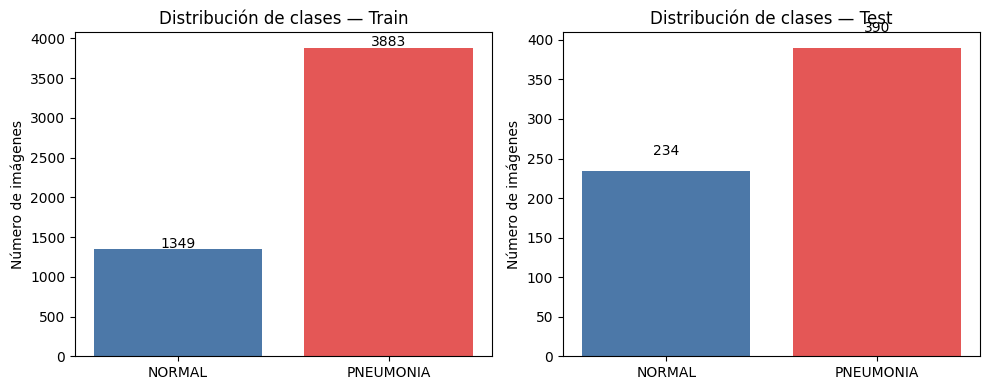

Train: PNEUMONIA=74.2% | Ratio PNEUMONIA/NORMAL=2.88x
Test: PNEUMONIA=62.5% | Ratio PNEUMONIA/NORMAL=1.67x


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, counts, title in zip(axes, [train_counts, test_counts], ["Train", "Test"]):
    labels, values = list(counts.keys()), list(counts.values())
    bars = ax.bar(labels, values, color=["#4C78A8", "#E45756"])
    ax.set_title(f"Distribución de clases — {title}")
    ax.set_ylabel("Número de imágenes")
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 20, str(v), ha="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_class_distribution.png", dpi=120)
plt.show()

for name, counts in [("Train", train_counts), ("Test", test_counts)]:
    total = sum(counts.values())
    ratio = counts["PNEUMONIA"] / counts["NORMAL"]
    print(f"{name}: PNEUMONIA={counts['PNEUMONIA']/total:.1%} | Ratio PNEUMONIA/NORMAL={ratio:.2f}x")

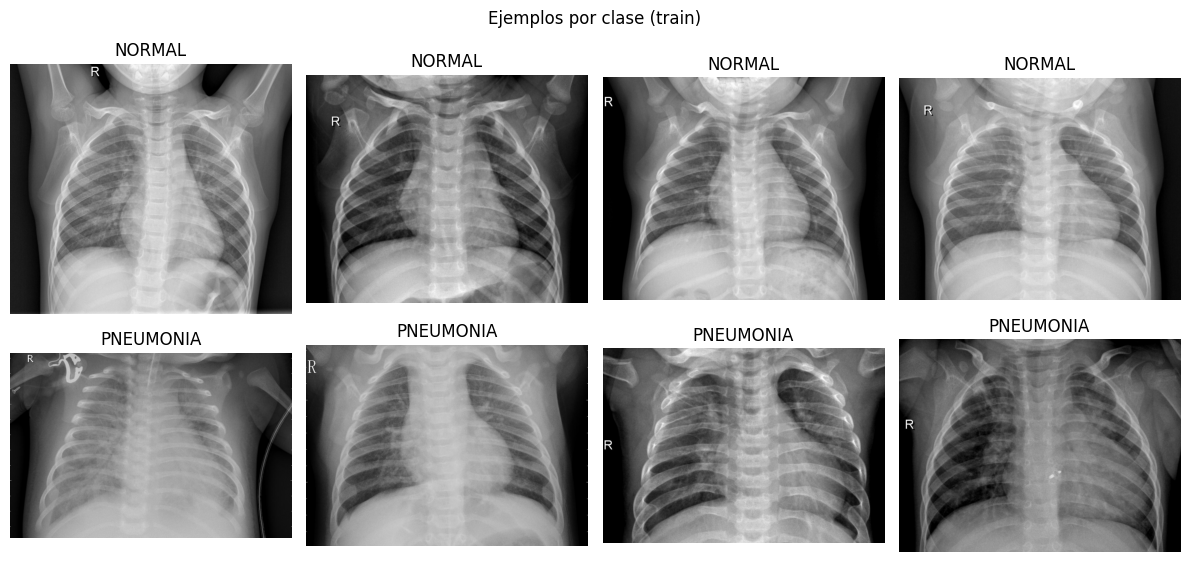

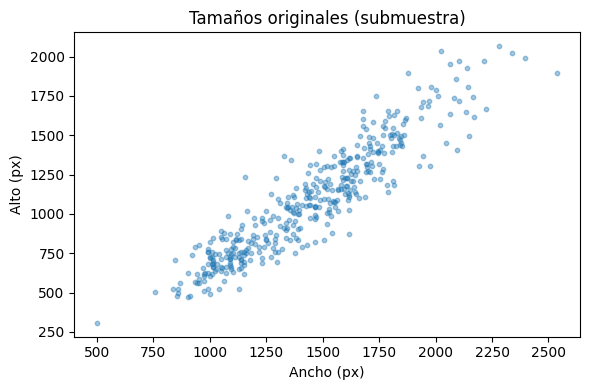

In [17]:
sample_paths = []
for cls in CLASSES:
    for p in list_images(TRAIN_DIR / cls)[:4]:
        sample_paths.append((p, cls))

widths, heights = [], []
for cls in CLASSES:
    for p in list_images(TRAIN_DIR / cls)[:200]:
        with Image.open(p) as im:
            widths.append(im.size[0])
            heights.append(im.size[1])

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, (path, cls) in zip(axes.flat, sample_paths):
    ax.imshow(Image.open(path).convert("L"), cmap="gray")
    ax.set_title(cls)
    ax.axis("off")
plt.suptitle("Ejemplos por clase (train)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_sample_images.png", dpi=120)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(widths, heights, alpha=0.4, s=10)
ax.set_xlabel("Ancho (px)")
ax.set_ylabel("Alto (px)")
ax.set_title("Tamaños originales (submuestra)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "eda_image_sizes.png", dpi=120)
plt.show()

## 4. Preprocesamiento: resize y normalización

In [18]:
def compute_mean_std(loader):
    channels_sum, channels_sqsum, n_batches = 0, 0, 0
    for data, _ in loader:
        channels_sum += data.mean(dim=[0, 2, 3])
        channels_sqsum += (data ** 2).mean(dim=[0, 2, 3])
        n_batches += 1
    mean = channels_sum / n_batches
    std = (channels_sqsum / n_batches - mean ** 2).sqrt()
    return mean.tolist(), std.tolist()

base_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

tmp_ds = datasets.ImageFolder(TRAIN_DIR, transform=base_transform)
tmp_loader = DataLoader(tmp_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
MEAN, STD = compute_mean_std(tmp_loader)
print("Mean/Std:", MEAN, STD)

Mean/Std: [0.4823513627052307] [0.23516277968883514]


In [19]:
def get_transforms(mean, std, augment=False):
    ops = [
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
    ]
    if augment:
        ops.append(transforms.RandomHorizontalFlip(p=0.5))
    ops.extend([transforms.ToTensor(), transforms.Normalize(mean=mean, std=std)])
    return transforms.Compose(ops)

train_transform = get_transforms(MEAN, STD, augment=True)
eval_transform = get_transforms(MEAN, STD, augment=False)

full_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
test_ds = datasets.ImageFolder(TEST_DIR, transform=eval_transform)
class_to_idx = full_train_ds.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}
print(class_to_idx)

{'NORMAL': 0, 'PNEUMONIA': 1}


## 5. División entrenamiento / validación (estratificada)

In [20]:
def stratified_indices(dataset, val_ratio=0.2, seed=42):
    labels = [dataset.samples[i][1] for i in range(len(dataset))]
    by_class = {}
    for i, y in enumerate(labels):
        by_class.setdefault(y, []).append(i)
    rng = random.Random(seed)
    train_idx, val_idx = [], []
    for idxs in by_class.values():
        rng.shuffle(idxs)
        n_val = int(len(idxs) * val_ratio)
        val_idx.extend(idxs[:n_val])
        train_idx.extend(idxs[n_val:])
    return train_idx, val_idx

train_idx, val_idx = stratified_indices(full_train_ds, VAL_RATIO, SEED)
train_ds = Subset(full_train_ds, train_idx)
val_ds = Subset(datasets.ImageFolder(TRAIN_DIR, transform=eval_transform), val_idx)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 4187 | Val: 1045 | Test: 624


In [21]:
def make_loaders(batch_size):
    kw = dict(num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True, **kw),
        DataLoader(val_ds, batch_size=batch_size, shuffle=False, **kw),
        DataLoader(test_ds, batch_size=batch_size, shuffle=False, **kw),
    )

train_loader, val_loader, test_loader = make_loaders(BATCH_SIZE)

## 6. Arquitectura CNN

In [22]:
class ChestXRayCNN(nn.Module):
    def __init__(self, num_classes=2, base_filters=32, kernel_size=3, dropout=0.5):
        super().__init__()
        pad = kernel_size // 2
        f1, f2, f3 = base_filters, base_filters * 2, base_filters * 4
        self.features = nn.Sequential(
            nn.Conv2d(1, f1, kernel_size, padding=pad),
            nn.BatchNorm2d(f1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(f1, f2, kernel_size, padding=pad),
            nn.BatchNorm2d(f2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(f2, f3, kernel_size, padding=pad),
            nn.BatchNorm2d(f3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        reduced = IMG_SIZE // 8
        flat_dim = f3 * reduced * reduced
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

demo = ChestXRayCNN()
print(demo)
print("Parámetros:", sum(p.numel() for p in demo.parameters()))

ChestXRayCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_fea

## 7. Entrenamiento, validación y métricas

In [23]:
def get_class_weights(dataset):
    if isinstance(dataset, Subset):
        labels = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        labels = dataset.targets
    counts = Counter(labels)
    n = len(labels)
    return torch.tensor([n / (len(counts) * counts[i]) for i in range(len(counts))], dtype=torch.float32)


def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss, y_true, y_pred = 0.0, [], []
    ctx = torch.enable_grad() if train_mode else torch.no_grad()
    with ctx:
        for images, labels in tqdm(loader, leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * images.size(0)
            preds = outputs.argmax(1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "y_true": y_true,
        "y_pred": y_pred,
    }
    return avg_loss, metrics


def train_model(model, train_loader, val_loader, epochs, lr, patience=4):
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    history = {k: [] for k in ["train_loss", "val_loss", "train_f1", "val_f1"]}
    best_f1, best_state, wait = -1.0, None, 0
    for epoch in range(1, epochs + 1):
        tr_loss, tr_m = run_epoch(model, train_loader, criterion, optimizer)
        va_loss, va_m = run_epoch(model, val_loader, criterion)
        for key, val in [("train_loss", tr_loss), ("val_loss", va_loss), ("train_f1", tr_m["f1"]), ("val_f1", va_m["f1"])]:
            history[key].append(val)
        print(f"Época {epoch}/{epochs} | train loss={tr_loss:.4f} f1={tr_m['f1']:.4f} | val loss={va_loss:.4f} f1={va_m['f1']:.4f}")
        if va_m["f1"] > best_f1:
            best_f1, best_state, wait = va_m["f1"], {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping")
                break
    if best_state:
        model.load_state_dict(best_state)
    return history, best_f1


class_weights = get_class_weights(full_train_ds)
print("Pesos de clase:", class_weights)

Pesos de clase: tensor([1.9392, 0.6737])


## 8. Entrenamiento baseline

In [24]:
baseline_model = ChestXRayCNN(base_filters=32, kernel_size=3, dropout=0.5).to(device)
baseline_history, baseline_best_f1 = train_model(
    baseline_model, train_loader, val_loader, epochs=1, lr=1e-3
)
print(f"Mejor F1 validación (baseline): {baseline_best_f1:.4f}")

Época 1/1 | train loss=0.8486 f1=0.8970 | val loss=0.1767 f1=0.9261
Mejor F1 validación (baseline): 0.9261


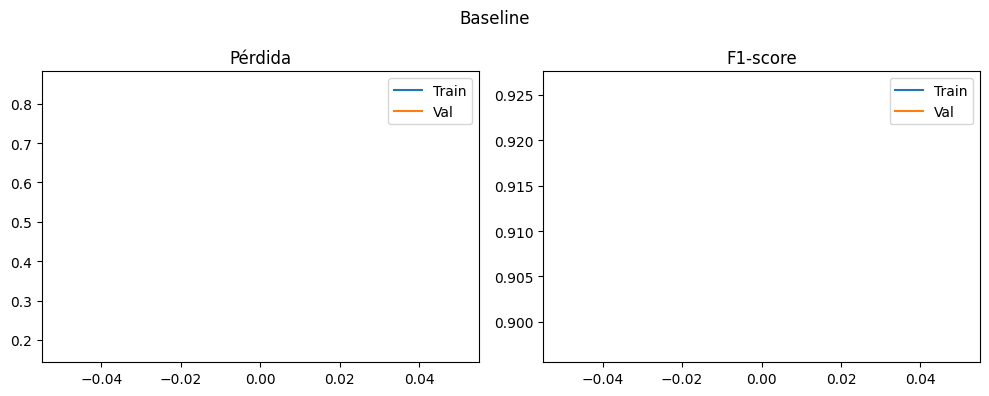

In [25]:
def plot_history(history, title, fname):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title("Pérdida")
    axes[0].legend()
    axes[1].plot(history["train_f1"], label="Train")
    axes[1].plot(history["val_f1"], label="Val")
    axes[1].set_title("F1-score")
    axes[1].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname, dpi=120)
    plt.show()

plot_history(baseline_history, "Baseline", "baseline_curves.png")

## 9. Random search de hiperparámetros

In [26]:
import itertools

# Grid reducido + pocas épocas por trial (CPU ligero; ver HP_TRIAL_* en §2)
HP_GRID = {
    "base_filters": [16, 32],
    "kernel_size": [3, 5],
    "lr": [5e-4, 1e-3],
    "epochs": HP_TRIAL_EPOCHS,
    "dropout": [0.3, 0.5],
}
rng = random.Random(SEED)
all_combos = list(itertools.product(*HP_GRID.values()))
search_combos = rng.sample(all_combos, min(N_RANDOM_TRIALS, len(all_combos)))
print(
    f"Grid total: {len(all_combos)} | Trials: {len(search_combos)} | "
    f"épocas por trial: {HP_TRIAL_EPOCHS}"
)

Grid total: 32 | Trials: 3 | épocas por trial: [1, 2]


In [27]:
keys = list(HP_GRID.keys())
search_results = []

for trial_id, combo in enumerate(search_combos, 1):
    hp = dict(zip(keys, combo))
    print(f"\nTrial {trial_id}: {hp}")
    model = ChestXRayCNN(
        base_filters=hp["base_filters"],
        kernel_size=hp["kernel_size"],
        dropout=hp["dropout"],
    ).to(device)
    history, best_f1 = train_model(
        model,
        train_loader,
        val_loader,
        epochs=hp["epochs"],
        lr=hp["lr"],
        patience=HP_TRIAL_PATIENCE,
    )
    _, val_m = run_epoch(model, val_loader, nn.CrossEntropyLoss(weight=class_weights.to(device)))
    search_results.append({**hp, "trial": trial_id, "val_f1": best_f1, "val_loss": history["val_loss"][-1],
                           "val_accuracy": val_m["accuracy"], "val_precision": val_m["precision"],
                           "val_recall": val_m["recall"]})

results_df = pd.DataFrame(search_results).sort_values("val_f1", ascending=False)
results_df


Trial 1: {'base_filters': 16, 'kernel_size': 3, 'lr': 0.001, 'epochs': 2, 'dropout': 0.5}


Época 1/2 | train loss=0.7039 f1=0.8957 | val loss=0.0975 f1=0.9642


Época 2/2 | train loss=0.1382 f1=0.9490 | val loss=0.1522 f1=0.9387
Early stopping



Trial 2: {'base_filters': 16, 'kernel_size': 3, 'lr': 0.0005, 'epochs': 1, 'dropout': 0.5}


Época 1/1 | train loss=0.3292 f1=0.9039 | val loss=0.1701 f1=0.9352



Trial 3: {'base_filters': 32, 'kernel_size': 3, 'lr': 0.0005, 'epochs': 1, 'dropout': 0.5}


Época 1/1 | train loss=0.5094 f1=0.8944 | val loss=0.0886 f1=0.9675


,base_filters,kernel_size,lr,epochs,dropout,trial,val_f1,val_loss,val_accuracy,val_precision,val_recall
2,32,3,0.0005,1,0.5,3,0.967464,0.088618,0.967464,0.967464,0.967464
0,16,3,0.0010,2,0.5,1,0.964207,0.152165,0.964593,0.964502,0.964593
1,16,3,0.0005,1,0.5,2,0.935187,0.170115,0.933014,0.945657,0.933014


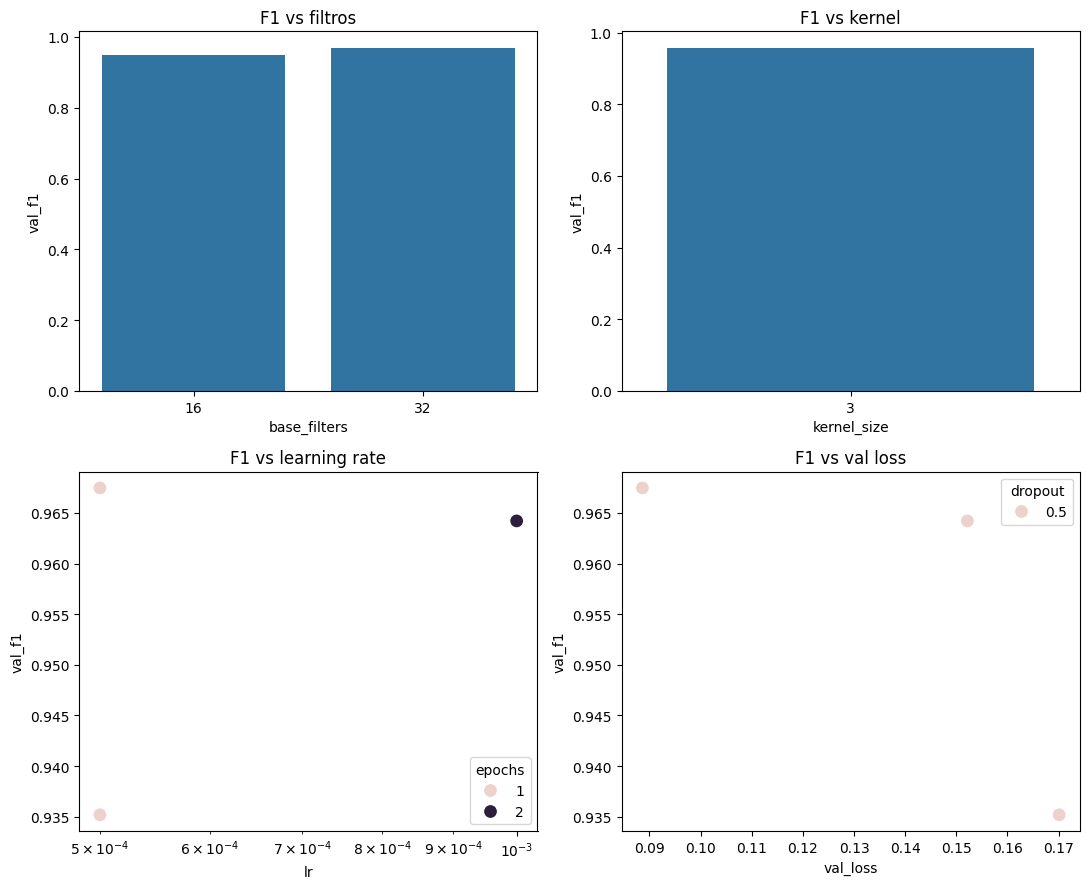

Mejor config:
 base_filters     32.000000
kernel_size       3.000000
lr                0.000500
epochs            1.000000
dropout           0.500000
trial             3.000000
val_f1            0.967464
val_loss          0.088618
val_accuracy      0.967464
val_precision     0.967464
val_recall        0.967464
Name: 2, dtype: float64


In [28]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
sns.barplot(data=results_df, x="base_filters", y="val_f1", ax=axes[0, 0], errorbar=None)
axes[0, 0].set_title("F1 vs filtros")
sns.barplot(data=results_df, x="kernel_size", y="val_f1", ax=axes[0, 1], errorbar=None)
axes[0, 1].set_title("F1 vs kernel")
sns.scatterplot(data=results_df, x="lr", y="val_f1", hue="epochs", ax=axes[1, 0], s=100)
axes[1, 0].set_xscale("log")
axes[1, 0].set_title("F1 vs learning rate")
sns.scatterplot(data=results_df, x="val_loss", y="val_f1", hue="dropout", ax=axes[1, 1], s=100)
axes[1, 1].set_title("F1 vs val loss")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "hyperparameter_search.png", dpi=120)
plt.show()

best_row = results_df.iloc[0]
print("Mejor config:\n", best_row)

### Reflexión sobre hiperparámetros

- **Filtros:** más capacidad, pero más riesgo de sobreajuste y mayor tiempo de cómputo.
- **Kernel:** tamaño 3 suele ser estable; 5 captura contexto más amplio.
- **Learning rate:** valores altos pueden diverger; bajos convergen lento.
- **Épocas:** más épocas no siempre mejoran F1 si hay sobreajuste.
- **Dropout:** regulariza; valores muy altos pueden impedir aprender.

Se selecciona la fila con mayor `val_f1` para el modelo final.

## 10. Entrenamiento final (mejores hiperparámetros)

Época 1/1 | train loss=0.4822 f1=0.9064 | val loss=0.1083 f1=0.9599
F1 validación final: 0.9599


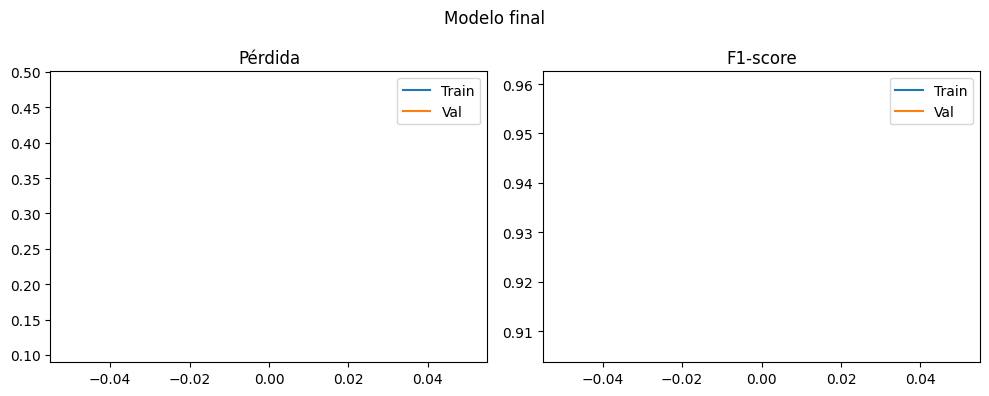

In [29]:
BEST_HP = {
    "base_filters": int(best_row["base_filters"]),
    "kernel_size": int(best_row["kernel_size"]),
    "lr": float(best_row["lr"]),
    "epochs": min(int(best_row["epochs"]), 2),
    "dropout": float(best_row["dropout"]),
}
final_model = ChestXRayCNN(**{k: BEST_HP[k] for k in ["base_filters", "kernel_size", "dropout"]}).to(device)
final_history, final_val_f1 = train_model(
    final_model, train_loader, val_loader, epochs=BEST_HP["epochs"], lr=BEST_HP["lr"], patience=5
)
print(f"F1 validación final: {final_val_f1:.4f}")
plot_history(final_history, "Modelo final", "final_curves.png")

## 11. Evaluación en test (conjunto independiente)

In [30]:
test_loss, test_m = run_epoch(final_model, test_loader, nn.CrossEntropyLoss(weight=class_weights.to(device)))
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy:  {test_m['accuracy']:.4f}")
print(f"Precision: {test_m['precision']:.4f}")
print(f"Recall:    {test_m['recall']:.4f}")
print(f"F1:        {test_m['f1']:.4f}")
print(classification_report(
    test_m["y_true"], test_m["y_pred"],
    target_names=[idx_to_class[i] for i in range(len(CLASSES))]
))

Loss: 1.1297
Accuracy:  0.6875
Precision: 0.7917
Recall:    0.6875
F1:        0.6071
              precision    recall  f1-score   support

      NORMAL       1.00      0.17      0.29       234
   PNEUMONIA       0.67      1.00      0.80       390

    accuracy                           0.69       624
   macro avg       0.83      0.58      0.54       624
weighted avg       0.79      0.69      0.61       624



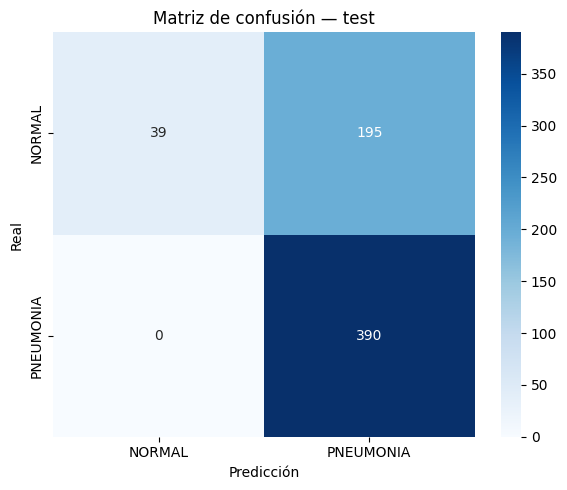

In [31]:
cm = confusion_matrix(test_m["y_true"], test_m["y_pred"])
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")
ax.set_title("Matriz de confusión — test")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_test.png", dpi=120)
plt.show()

## 12. Conclusiones

1. El dataset está **desbalanceado** (más PNEUMONIA); se usaron pesos en la pérdida.
2. Preprocesamiento: escala de grises, resize y normalización con estadísticas del train.
3. CNN con convolución, pooling, capas densas y **dropout**.
4. **Random search** optimizó filtros, kernel, lr, épocas y dropout usando F1 en validación.
5. **Test** reservado para métricas finales y matriz de confusión.

In [32]:
results_df.to_csv(OUTPUT_DIR / "hyperparameter_search_results.csv", index=False)
torch.save(final_model.state_dict(), OUTPUT_DIR / "best_cnn_model.pth")
print("Guardado en", OUTPUT_DIR.resolve())

Guardado en C:\IC\Machine Learning II\outputs
